# Encoder/Decoder

## EDA

In [3]:
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='mps')

In [ ]:
from torch.utils.data import DataLoader
from torchvision.datasets import STL10
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = STL10(
    root="./data",
    split="train",
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

len(train_dataset)

100%|██████████| 2.64G/2.64G [19:14<00:00, 2.29MB/s]  


5000

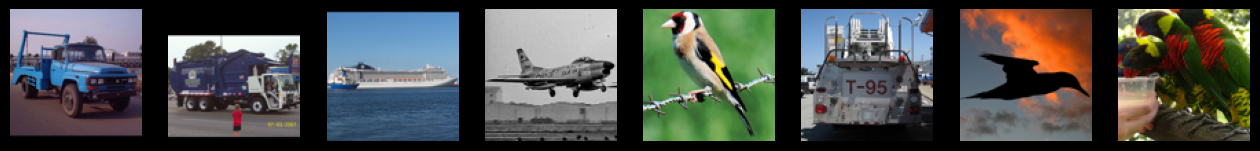

In [2]:
import matplotlib.pyplot as plt
import numpy as np

batch = next(iter(train_loader))
images, labels = batch

images = images[:8]

def denorm(img):
    img = img * 0.5 + 0.5
    return np.transpose(img.numpy(), (0, 2, 3, 1))

imgs = denorm(images)

plt.style.use("dark_background")
fig, axes = plt.subplots(1, 8, figsize=(16, 3))

for i in range(8):
    axes[i].imshow(imgs[i])
    axes[i].axis("off")

plt.show()

## Baseline

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(256 * 6 * 6, latent_dim)
        self.fc_logvar = nn.Linear(256 * 6 * 6, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, 256 * 6 * 6)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Tanh()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(x.size(0), 256, 6, 6)
        x = self.decoder(x)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [5]:
def vae_loss(recon, x, mu, logvar):
    recon_loss = F.mse_loss(recon, x, reduction="sum")

    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss

In [6]:
model = VAE(latent_dim=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 30

loss_history = []
recon_history = []
kl_history = []

model.train()

for epoch in range(epochs):
    total_loss = 0
    total_recon = 0
    total_kl = 0

    for x, _ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(x)

        recon_loss = torch.nn.functional.mse_loss(recon, x, reduction="sum")
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        loss = recon_loss + kl_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    loss_history.append(total_loss / len(train_dataset))
    recon_history.append(total_recon / len(train_dataset))
    kl_history.append(total_kl / len(train_dataset))

    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss_history[-1]:.4f}")

Epoch 1/30 | Loss: 6538.5599
Epoch 2/30 | Loss: 4369.8150
Epoch 3/30 | Loss: 3407.6952
Epoch 4/30 | Loss: 3111.9737
Epoch 5/30 | Loss: 2878.3629
Epoch 6/30 | Loss: 2717.6017
Epoch 7/30 | Loss: 2616.2862
Epoch 8/30 | Loss: 2520.2848
Epoch 9/30 | Loss: 2404.8554
Epoch 10/30 | Loss: 2245.4374
Epoch 11/30 | Loss: 2120.0846
Epoch 12/30 | Loss: 2072.9598
Epoch 13/30 | Loss: 2016.3664
Epoch 14/30 | Loss: 1950.4825
Epoch 15/30 | Loss: 1911.9826
Epoch 16/30 | Loss: 1883.3433
Epoch 17/30 | Loss: 1867.4681
Epoch 18/30 | Loss: 1816.5831
Epoch 19/30 | Loss: 1801.9399
Epoch 20/30 | Loss: 1771.9179
Epoch 21/30 | Loss: 1814.5084
Epoch 22/30 | Loss: 1712.8860
Epoch 23/30 | Loss: 1692.6615
Epoch 24/30 | Loss: 1665.6799
Epoch 25/30 | Loss: 1645.2536
Epoch 26/30 | Loss: 1633.2217
Epoch 27/30 | Loss: 1603.4368
Epoch 28/30 | Loss: 1583.1293
Epoch 29/30 | Loss: 1672.7585
Epoch 30/30 | Loss: 1556.4749


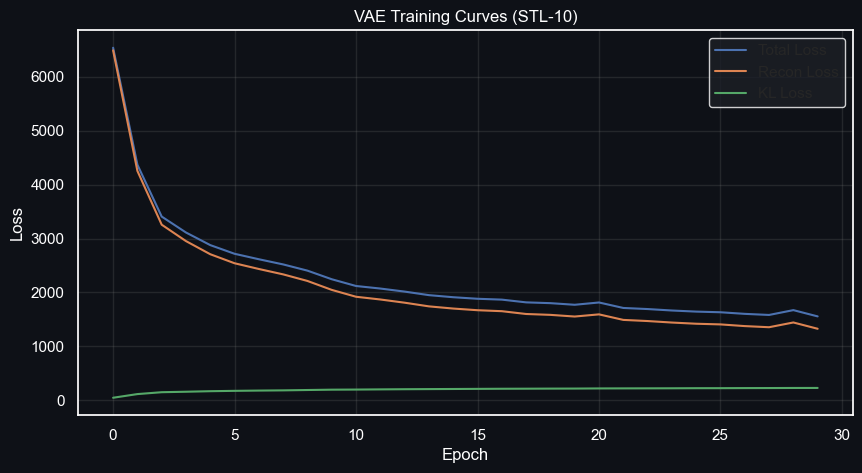

In [14]:
import matplotlib.pyplot as plt

plt.close("all")

fig, ax = plt.subplots(figsize=(10, 5))

fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

ax.plot(loss_history, label="Total Loss")
ax.plot(recon_history, label="Recon Loss")
ax.plot(kl_history, label="KL Loss")

ax.set_xlabel("Epoch", color="white")
ax.set_ylabel("Loss", color="white")
ax.set_title("VAE Training Curves (STL-10)", color="white")

ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_color("white")

leg = ax.legend()
leg.get_frame().set_facecolor("#1c1f26")
leg.get_frame().set_edgecolor("white")

ax.grid(alpha=0.2, color="gray")

plt.show()

### Визуализация

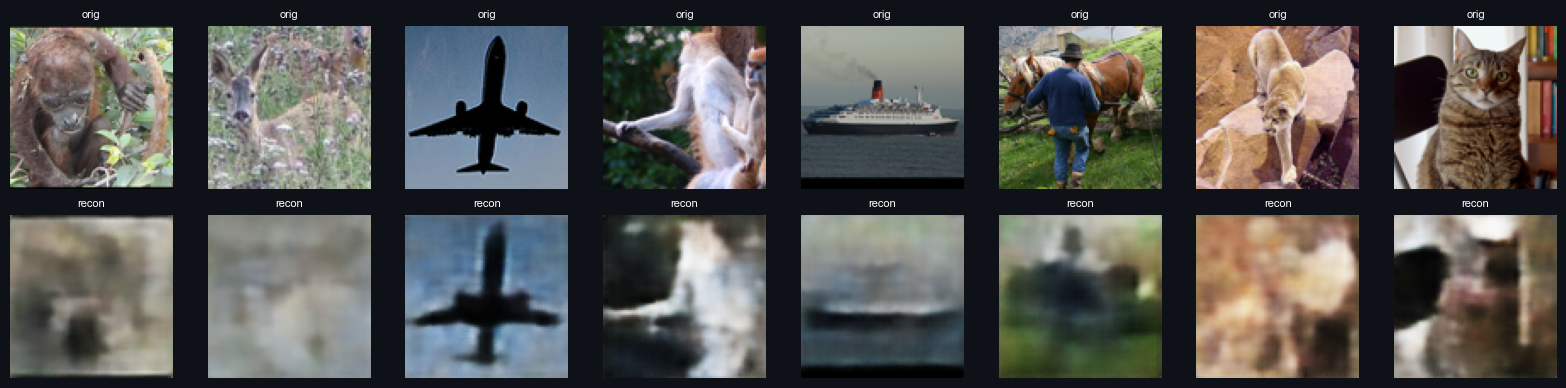

In [15]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

x, _ = next(iter(train_loader))
x = x[:8].to(device)

with torch.no_grad():
    recon, _, _ = model(x)

x = x.cpu()
recon = recon.cpu()

def denorm(img):
    img = img * 0.5 + 0.5
    return np.transpose(img.numpy(), (0, 2, 3, 1))

x_img = denorm(x)
recon_img = denorm(recon)

plt.close("all")

fig, ax = plt.subplots(2, 8, figsize=(16, 4))

fig.patch.set_facecolor("#0e1117")

for i in range(8):
    ax[0, i].imshow(x_img[i])
    ax[0, i].axis("off")
    ax[0, i].set_title("orig", color="white", fontsize=8)

    ax[1, i].imshow(recon_img[i])
    ax[1, i].axis("off")
    ax[1, i].set_title("recon", color="white", fontsize=8)

plt.tight_layout()
plt.show()

## Вывод:

#### Большая часть картинок восстанавливается верно, но сильный блюр. Baseline работает нормально

## Улушения baseline

In [16]:
class ExperimentVAE(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()

        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(512 * 6 * 6, latent_dim)
        self.fc_logvar = nn.Linear(512 * 6 * 6, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, 512 * 6 * 6)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(x.size(0), 512, 6, 6)
        return self.decoder(x)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [17]:
def train_vae_model2(model, dataloader, optimizer, device, epochs=30):
    model.to(device)

    losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, _ in dataloader:
            x = x.to(device)

            optimizer.zero_grad()

            recon, mu, logvar = model(x)

            recon_loss = F.mse_loss(recon, x, reduction='sum')
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

            loss = recon_loss + kl_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader.dataset)
        losses.append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

    return losses

In [18]:
model2 = ExperimentVAE(latent_dim=256).to(device)
optimizer = torch.optim.Adam(model2.parameters(), lr=1e-3)

losses_model2 = train_vae_model2(
    model2,
    train_loader,
    optimizer,
    device,
    epochs=30
)

Epoch 1/30 | Loss: 6580328039047822336.0000
Epoch 2/30 | Loss: 372045.8793
Epoch 3/30 | Loss: 44915565.8356
Epoch 4/30 | Loss: 7330.6712
Epoch 5/30 | Loss: 6051.8900
Epoch 6/30 | Loss: 18038.8817
Epoch 7/30 | Loss: 214925.2454
Epoch 8/30 | Loss: 6136.0074
Epoch 9/30 | Loss: 5287.0904
Epoch 10/30 | Loss: 1987511.0724
Epoch 11/30 | Loss: 4518.7028
Epoch 12/30 | Loss: 5126.7739
Epoch 13/30 | Loss: 4307.1607
Epoch 14/30 | Loss: 7383.6513
Epoch 15/30 | Loss: 4124.5351
Epoch 16/30 | Loss: 4097.1037
Epoch 17/30 | Loss: 119325.4897
Epoch 18/30 | Loss: 4116.4389
Epoch 19/30 | Loss: 4586.6650
Epoch 20/30 | Loss: 3944.2989
Epoch 21/30 | Loss: 3873.5304
Epoch 22/30 | Loss: 3911.0158
Epoch 23/30 | Loss: 3766.0287
Epoch 24/30 | Loss: 4048.2897
Epoch 25/30 | Loss: 3754.0896
Epoch 26/30 | Loss: 3925.4370
Epoch 27/30 | Loss: 3649.1910
Epoch 28/30 | Loss: 3687.6854
Epoch 29/30 | Loss: 3542.1735
Epoch 30/30 | Loss: 3522.5195


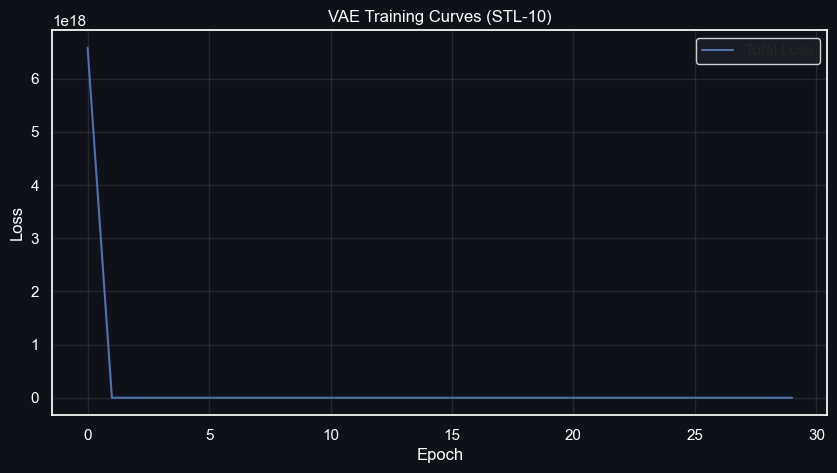

In [20]:
import matplotlib.pyplot as plt

plt.close("all")

fig, ax = plt.subplots(figsize=(10, 5))

fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

ax.plot(losses_model2, label="Total Loss")


ax.set_xlabel("Epoch", color="white")
ax.set_ylabel("Loss", color="white")
ax.set_title("VAE Training Curves (STL-10)", color="white")

ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_color("white")

leg = ax.legend()
leg.get_frame().set_facecolor("#1c1f26")
leg.get_frame().set_edgecolor("white")

ax.grid(alpha=0.2, color="gray")

plt.show()